In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random
from supersuit import frame_skip_v0, resize_v1, frame_stack_v1, reshape_v0
from diffusers import AutoencoderKL
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Dataset

In [ ]:
def get_env_from_id(id: str):
    if id == "boxing":
        from pettingzoo.atari import boxing_v2
        return boxing_v2.parallel_env
    else:
        raise ValueError(f"Environment {id} not found")

def env_fn(env_func):
    env = env_func(render_mode="rgb_array")
    env = frame_skip_v0(env, num_frames=4)
    env = resize_v1(env, x_size=64, y_size=64)
    return env

def env_loop(env_func, **kwargs):
    previous_actions_weight = kwargs.get('previous_actions_weight', 0.75)
    env = env_fn(env_func=env_func)
    observations, infos = env.reset(seed=42) # Add seed for reproducibility
    memory = defaultdict(list)

    while env.agents:
        actions = {}
        for agent in env.agents:
            if len(memory[agent]) > 0 and random.random() < previous_actions_weight:
                actions[agent] = memory[agent][-1]
            else:
                actions[agent] = env.action_space(agent).sample()

        for agent, action in actions.items():
            memory[agent].append(action)

        next_observations, rewards, terminations, truncations, infos = env.step(actions)

        # We only care about observations for VAE training
        # Yielding observation for 'first_0' agent. Modify if you need both or different agents.
        if 'first_0' in next_observations:
            yield next_observations['first_0']
        else: # Game might have ended for 'first_0'
            if not env.agents: # if all agents are done
                break
            # If only 'first_0' is done but 'second_0' is not, we might get an empty obs
            # For simplicity, let's just break if 'first_0' is not available.
            # A more robust solution would handle cases where one agent is done.
            # Or, if the goal is to collect all frames, iterate through available agents.
            if 'second_0' in next_observations and 'first_0' not in env.agents: # if first_0 is done
                 if env.agents: # if other agents are still active
                    active_agent = env.agents[0] # pick an active agent
                    yield next_observations[active_agent]
                 else:
                    break

            elif not env.agents:
                break


class AtariDataset(Dataset):
    def __init__(self, transform=None, seq_length_for_collection=4):
        self.frames_data = []
        self.transform = transform
        self.seq_length_for_collection = seq_length_for_collection

    def __len__(self):
        return len(self.frames_data)

    def __getitem__(self, idx):
        frame = self.frames_data[idx]
        if self.transform:
            frame = self.transform(frame)
        return frame

    def _to_tensor(self, x):
        return torch.tensor(x, device='cuda').div(255).mul(2).sub(1).permute(0, 3, 1, 2).contiguous()

    def collect_dataset(self, env_loop_generator_fn, episodes: int = 100, frames_per_episode_segment: int = 32):
        print(f"Collecting dataset for {episodes} episodes...")
        all_collected_frames = []
        for episode_num in tqdm(range(episodes), desc="Collecting Episodes"):
            episode_frames = []
            env_iter = iter(env_loop_generator_fn())
            try:
                for observation_first_0 in env_iter:
                    episode_frames.append(observation_first_0) # already select first_0
            except StopIteration:
                pass

            if len(episode_frames) > self.seq_length_for_collection: # Ensure enough frames
                # Sample segments from this episode.
                # frames_per_episode_segment determines how many frames to sample from this one episode.
                # We ensure we don't pick overlapping sequences that are too short.
                num_possible_starts = len(episode_frames) - self.seq_length_for_collection + 1
                if num_possible_starts > 0:
                    actual_samples_from_episode = min(frames_per_episode_segment, num_possible_starts)
                    indices = random.sample(range(num_possible_starts), actual_samples_from_episode)

                    for start_idx in indices:
                        # The original code added individual frames from a sequence.
                        # Let's continue that pattern. If sequences are needed, __getitem__ should return a sequence.
                        # For an image VAE, individual frames are fine.
                        segment = episode_frames[start_idx : start_idx + self.seq_length_for_collection]
                        all_collected_frames.extend(segment) # Add all frames from the sampled segment

        self.frames_data = all_collected_frames
        print(f"Collected {len(self.frames_data)} frames in total.")

def vae_loss_fn(recon_x, x, mu, log_var, kl_weight=1.0):
    # Ensure x is in the same range as recon_x if necessary.
    # Diffusers VAE output is typically [-1, 1], input should also be [-1, 1]
    recon_loss = F.mse_loss(recon_x, x, reduction='sum') / x.shape[0] # per batch item
    # KL Divergence
    kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=[1,2,3])
    kl_div = torch.mean(kl_div) # mean over batch
    return recon_loss + kl_weight * kl_div

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
vae_model_id = "stabilityai/sd-vae-ft-mse"
vae = AutoencoderKL.from_pretrained(vae_model_id).to(device)
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
model_parameters = sum(p.numel() for p in vae.parameters())
print(f"Total parameters: {model_parameters}")

Total parameters: 83653863


In [ ]:
def build_dataloader(batch_size, seq_length_for_collection=4, episodes=100):
    atari_dataset = AtariDataset(transform=transform, seq_length_for_collection=seq_length_for_collection)
    atari_dataset.collect_dataset(
        lambda: env_loop(env_func=get_env_from_id("boxing"), previous_actions_weight=0.3),
        episodes=episodes,
        frames_per_episode_segment=64
    )

    if len(atari_dataset) == 0:
        raise ValueError("Dataset is empty! Check collection logic or environment interaction.")

    batch_size = batch_size
    loader = DataLoader(atari_dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
    return loader

In [ ]:
train_loader = build_dataloader(batch_size=64, seq_length_for_collection=500, episodes=1000)
val_loader = build_dataloader(batch_size=64, seq_length_for_collection=500, episodes=50)

Collected 32000000 frames in total.


Collected 1600000 frames in total.


# Check output when inference

In [ ]:
def check(dataloader):
    vae.eval()
    original_samples = []
    reconstructed_samples_zero_shot = []
    try:
        sample_batch = next(iter(dataloader))
        sample_batch = sample_batch.to(device)

        with torch.no_grad():
            posterior = vae.encode(sample_batch).latent_dist
            z = posterior.sample()
            reconstruction = vae.decode(z).sample
        for i in range(min(sample_batch.size(0), 8)):
            original_img = sample_batch[i].cpu().permute(1, 2, 0) * 0.5 + 0.5 # Denormalize
            reconstructed_img = reconstruction[i].cpu().permute(1, 2, 0) * 0.5 + 0.5 # Denormalize
            original_samples.append(original_img.numpy().clip(0,1))
            reconstructed_samples_zero_shot.append(reconstructed_img.numpy().clip(0,1))

        # Plotting
        n_plot = len(original_samples)
        if n_plot > 0:
            fig, axs = plt.subplots(2, n_plot, figsize=(n_plot * 2, 4))
            for i in range(n_plot):
                axs[0, i].imshow(original_samples[i])
                axs[0, i].set_title("Original")
                axs[0, i].axis("off")
                axs[1, i].imshow(reconstructed_samples_zero_shot[i])
                axs[1, i].set_title("Zero-shot Recon")
                axs[1, i].axis("off")
            plt.suptitle("VAE Reconstruction (Boxing 64x64)")
            plt.tight_layout()
            plt.show()
        else:
            print("No samples to show for zero-shot reconstruction.")

    except StopIteration:
        print("Train loader is empty, cannot perform zero-shot visualization.")

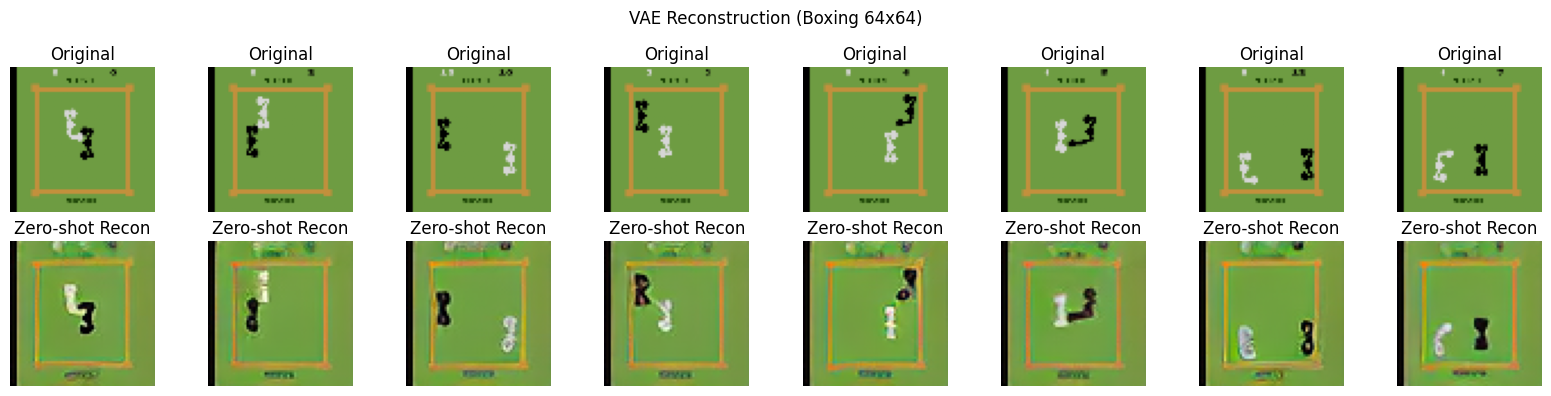

In [ ]:
check(train_loader)
# pretrain output

# Train

In [ ]:
optimizer = optim.AdamW(vae.parameters(), lr=1e-4)
num_epochs_finetune = 50
kl_weight_schedule = np.linspace(0.0001, 1.0, num_epochs_finetune)

In [ ]:
train_losses_epoch = []
val_losses_epoch = []
best_val_loss = float('inf')
best_epoch = 0
checkpoint_dir = "/content/drive/MyDrive/vae_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
best_checkpoint_path = os.path.join(checkpoint_dir, "vae_finetuned_boxing_best.pt")

for epoch in range(num_epochs_finetune):
    vae.train()
    epoch_train_loss = 0
    current_kl_weight = kl_weight_schedule[epoch]
    progress_bar_train = tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{num_epochs_finetune}")

    for batch_idx, x_train in enumerate(progress_bar_train):
        x_train = x_train.to(device)
        optimizer.zero_grad()

        posterior_train = vae.encode(x_train).latent_dist
        z_train = posterior_train.sample()
        x_hat_train = vae.decode(z_train).sample

        loss_train = vae_loss_fn(x_hat_train, x_train, posterior_train.mean, posterior_train.logvar, kl_weight=current_kl_weight)
        loss_train.backward()
        optimizer.step()

        epoch_train_loss += loss_train.item()
        progress_bar_train.set_postfix({"loss": loss_train.item(), "KL_w": f"{current_kl_weight:.4f}"})

    avg_epoch_train_loss = epoch_train_loss / len(train_loader)
    train_losses_epoch.append(avg_epoch_train_loss)
    print(f"Epoch {epoch+1}/{num_epochs_finetune}, Avg Train Loss: {avg_epoch_train_loss:.4f}, KL Weight: {current_kl_weight:.4f}")

    vae.eval()
    epoch_val_loss = 0
    progress_bar_val = tqdm(val_loader, desc=f"Valid Epoch {epoch+1}/{num_epochs_finetune}")
    with torch.no_grad():
        for x_val in progress_bar_val:
            x_val = x_val.to(device)

            posterior_val = vae.encode(x_val).latent_dist

            z_val = posterior_val.sample()
            x_hat_val = vae.decode(z_val).sample

            loss_val = vae_loss_fn(x_hat_val, x_val, posterior_val.mean, posterior_val.logvar, kl_weight=1.0)
            epoch_val_loss += loss_val.item()
            progress_bar_val.set_postfix({"loss": loss_val.item()})

    avg_epoch_val_loss = epoch_val_loss / len(val_loader)
    val_losses_epoch.append(avg_epoch_val_loss)
    print(f"Epoch {epoch+1}/{num_epochs_finetune}, Avg Val Loss: {avg_epoch_val_loss:.4f}")

    if avg_epoch_val_loss < best_val_loss:
        best_val_loss = avg_epoch_val_loss
        best_epoch = epoch + 1
        torch.save(vae.state_dict(), best_checkpoint_path)
        print(f"New best validation loss: {best_val_loss:.4f} at epoch {best_epoch}. Checkpoint saved to {best_checkpoint_path}")

print("Fine-tuning finished.")
print(f"Best validation loss of {best_val_loss:.4f} achieved at epoch {best_epoch}")

Train Epoch 1/50:   5%|▍         | 22530/500000 [9:30:43<201:35:10,  1.52s/it, loss=0.353, KL_w=0.0001]


KeyboardInterrupt: 

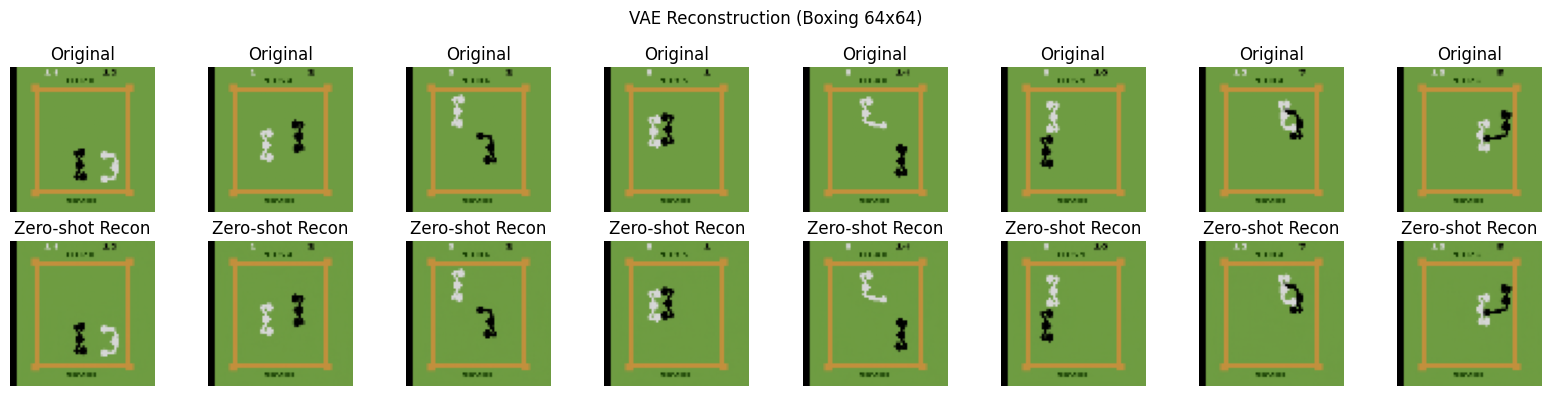

In [ ]:
check(val_loader)

In [ ]:
torch.save(vae.state_dict(), best_checkpoint_path)

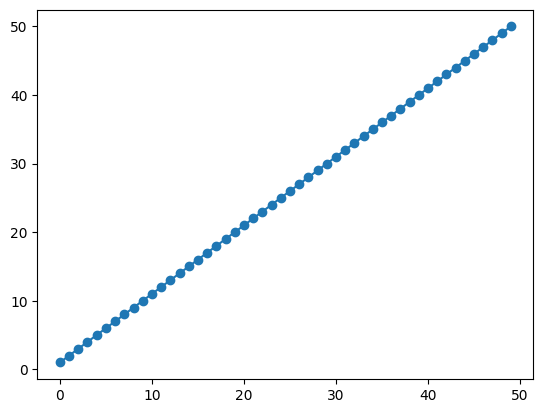

In [ ]:
plt.plot(epochs_range, train_losses_epoch, label='Average Training Loss', marker='o')

ValueError: x and y must have same first dimension, but have shapes (50,) and (0,)

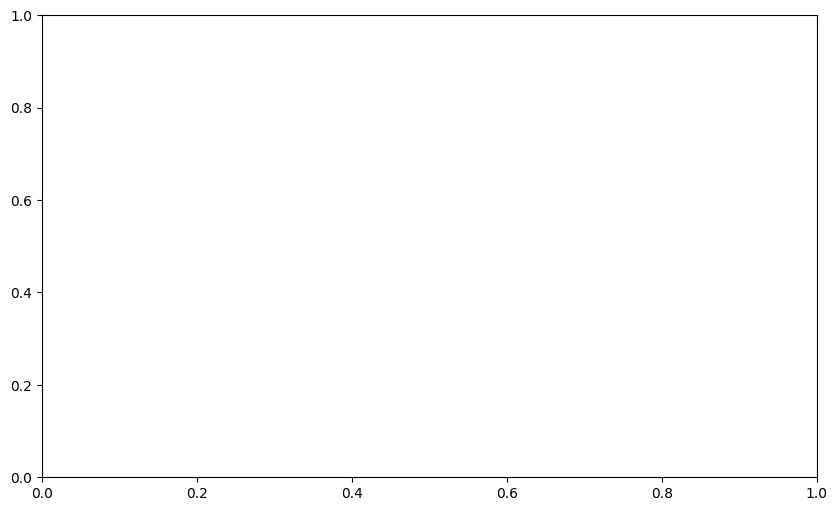

In [ ]:
plt.figure(figsize=(10, 6))
epochs_range = range(1, num_epochs_finetune + 1)
plt.plot(epochs_range, train_losses_epoch, label='Average Training Loss', marker='o')
# plt.plot(epochs_range, val_losses_epoch, label='Average Validation Loss', marker='x')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs_range) # Ensure all epoch numbers are shown as ticks if not too many
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(checkpoint_dir, "training_validation_loss_plot.png")) # Save the plot
plt.show()

In [ ]:
if os.path.exists(best_checkpoint_path):
    print(f"\nLoading best VAE from: {best_checkpoint_path}")
    vae = AutoencoderKL.from_pretrained(vae_model_id) # Load fresh architecture
    vae.load_state_dict(torch.load(best_checkpoint_path))
    vae = vae.to(device)
    vae.eval()


Loading best VAE from: /content/drive/MyDrive/vae_checkpoints/vae_finetuned_boxing_best.pt


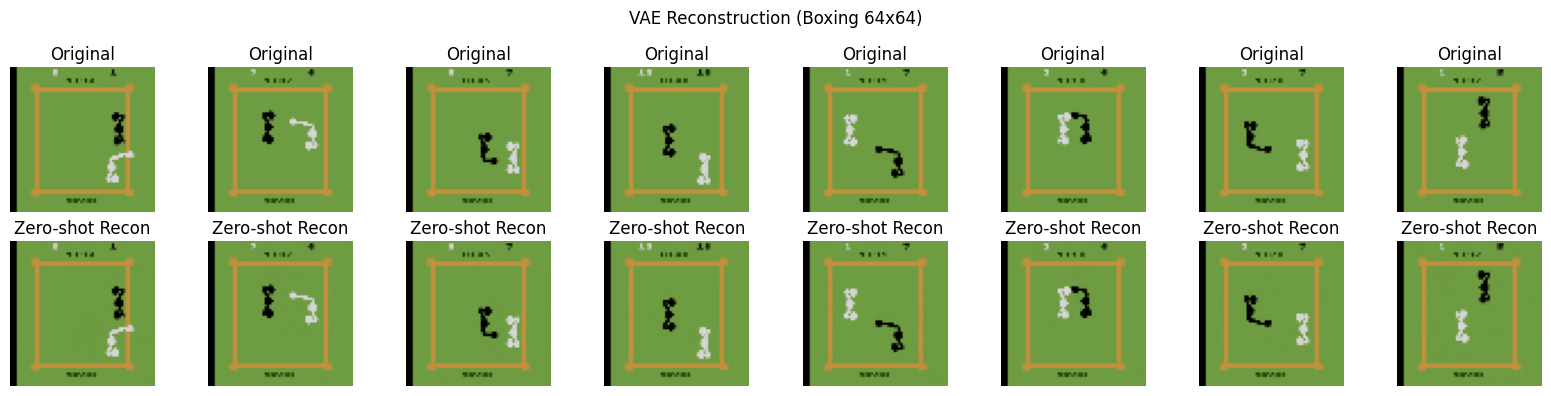

In [ ]:
check(val_loader)